### Choice of the coils 

Per scegliere le spire, dvido la città in rettangoli e scelgo per ciascuna zona una spira più vicina al centro del rettangolo. In totale ci sono 100 aree della città e quindi 100 spire.
 Parameters
    ----------
    df : DataFrame
        Deve contenere latitudine e longitudine
    n_lat : int
        numero di celle in latitudine
    n_lon : int
        numero di celle in longitudine
    mode : str
        - "centroid": prende il sensore più vicino al centro cella
        - "random": prende un sensore casuale per cella
    """

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import os
import numpy as np
import pandas as pd
import seaborn as sns




df = pd.read_parquet('../data/processed/dataset_finale_2023-09-01_2025-09-30.parquet')
df.head()

,data,id_uni,chiave,nome_via,direzione,longitudine,latitudine,fascia_oraria,conteggio_veicoli,ora,...,data_str,festivo_nazionale,nome_festivita,festa_locale,evento_traffico,tipo_evento,impatto_evento,score_evento,eventi_sovrapposti,tipo_giorno
0,2023-09-01,179,41,VIA OLINDO GUERRINI,N,11.321014,44.496985,00_00_01_00,259,0,...,2023-09-01,False,NaN,False,NaN,NaN,NaN,0,0,feriale
1,2023-09-01,179,41,VIA OLINDO GUERRINI,N,11.321014,44.496985,01_00_02_00,5,1,...,2023-09-01,False,NaN,False,NaN,NaN,NaN,0,0,feriale
2,2023-09-01,179,41,VIA OLINDO GUERRINI,N,11.321014,44.496985,02_00_03_00,7,2,...,2023-09-01,False,NaN,False,NaN,NaN,NaN,0,0,feriale
3,2023-09-01,179,41,VIA OLINDO GUERRINI,N,11.321014,44.496985,03_00_04_00,6,3,...,2023-09-01,False,NaN,False,NaN,NaN,NaN,0,0,feriale
4,2023-09-01,179,41,VIA OLINDO GUERRINI,N,11.321014,44.496985,04_00_05_00,1410,4,...,2023-09-01,False,NaN,False,NaN,NaN,NaN,0,0,feriale


In [2]:
veicoli_medi_per_spira = (
    df.groupby(['chiave', 'data'])['conteggio_veicoli']
    .sum()
    .groupby('chiave')
    .mean()
    .rename("veicoli_medi")
)
# merge con il dataframe delle coordinate
df_mappa = df.merge(veicoli_medi_per_spira, on='chiave')

In [3]:
os.environ["BROWSER"] = "chrome" 
pio.renderers.default = "browser"

def map_coils(df):
    fig = px.scatter_map(
        df[['chiave', 'latitudine', 'longitudine','veicoli_medi']].drop_duplicates(subset='chiave'),
        lat="latitudine",
        lon="longitudine",
        hover_name="chiave",
        # size='veicoli_medi',
        zoom=11,
        height=600
    )

    fig.update_layout(
        mapbox_style="open-street-map",  # non richiede token
        margin={"r":0, "t":0, "l":0, "b":0}
    )

    fig.write_html("mappa.html")
map_coils(df_mappa)

### Coils accuracy management

Percentage of time in which accuracy is lower than 75% for each coil. 

In [4]:
df_mappa.chiave.unique()

array([ 41,  83, 106, 187, 201, 251, 432, 449, 505, 513, 525, 546, 600,
       683, 725, 760, 796, 833, 839, 843, 896])

In [5]:
drop_id = df.groupby('chiave')['accuratezza'].apply(lambda x: round((x > 50).sum()/len(x)*100, 2))
drop_id

chiave
41     42.04
83     93.56
106    77.35
187    95.95
201    98.65
251    42.44
432    97.97
449    90.33
505    92.09
513    97.27
525    96.80
546    97.42
600    97.38
683    97.68
725    79.94
760    97.84
796    81.94
833    86.67
839    97.45
843    97.68
896    97.90
Name: accuratezza, dtype: float64

Drop coils that have an accuracy lower than 50% for more than 75% of time considered. 

In [6]:
df = df[~df['chiave'].isin([41, 251])]

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 347016 entries, 18264 to 383543
Data columns (total 33 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   data                347016 non-null  str           
 1   id_uni              347016 non-null  int64         
 2   chiave              347016 non-null  int64         
 3   nome_via            347016 non-null  str           
 4   direzione           347016 non-null  str           
 5   longitudine         347016 non-null  float64       
 6   latitudine          347016 non-null  float64       
 7   fascia_oraria       347016 non-null  str           
 8   conteggio_veicoli   347016 non-null  int64         
 9   ora                 347016 non-null  int64         
 10  timestamp           347016 non-null  datetime64[us]
 11  temperature_2m      347016 non-null  float64       
 12  precipitation       347016 non-null  float64       
 13  rain                347016 non-null  floa

There are some days in which coils the coils are under maintenance. In those days, we find Nan values in dataset. We got 1784 nan values. 
It is necessary these values from dataset. 

In [8]:
df[df['accuratezza'].isna()]

,data,id_uni,chiave,nome_via,direzione,longitudine,latitudine,fascia_oraria,conteggio_veicoli,ora,...,data_str,festivo_nazionale,nome_festivita,festa_locale,evento_traffico,tipo_evento,impatto_evento,score_evento,eventi_sovrapposti,tipo_giorno
22618,2024-02-29,597,83,VIA ANDREA COSTA,O,11.311224,44.494098,10_00_11_00,0,10,...,2024-02-29,False,NaN,False,NaN,NaN,NaN,0,0,feriale
22619,2024-02-29,597,83,VIA ANDREA COSTA,O,11.311224,44.494098,11_00_12_00,0,11,...,2024-02-29,False,NaN,False,NaN,NaN,NaN,0,0,feriale
22620,2024-02-29,597,83,VIA ANDREA COSTA,O,11.311224,44.494098,12_00_13_00,0,12,...,2024-02-29,False,NaN,False,NaN,NaN,NaN,0,0,feriale
23354,2024-03-31,597,83,VIA ANDREA COSTA,O,11.311224,44.494098,02_00_03_00,0,2,...,2024-03-31,True,Pasqua,False,NaN,NaN,NaN,0,0,festivo
24599,2024-05-21,597,83,VIA ANDREA COSTA,O,11.311224,44.494098,23_00_24_00,0,23,...,2024-05-21,False,NaN,False,NaN,NaN,NaN,0,0,feriale
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382013,2025-07-29,117,896,VIALE GIAN BATTISTA ERCOLANI,S,11.357050,44.493602,05_00_06_00,0,5,...,2025-07-29,False,NaN,False,NaN,NaN,NaN,0,0,feriale
382014,2025-07-29,117,896,VIALE GIAN BATTISTA ERCOLANI,S,11.357050,44.493602,06_00_07_00,332,6,...,2025-07-29,False,NaN,False,NaN,NaN,NaN,0,0,feriale
382994,2025-09-08,117,896,VIALE GIAN BATTISTA ERCOLANI,S,11.357050,44.493602,02_00_03_00,44,2,...,2025-09-08,False,NaN,False,NaN,NaN,NaN,0,0,feriale
382995,2025-09-08,117,896,VIALE GIAN BATTISTA ERCOLANI,S,11.357050,44.493602,03_00_04_00,0,3,...,2025-09-08,False,NaN,False,NaN,NaN,NaN,0,0,feriale


In [9]:
df = df[df['accuratezza'].notna()]

In [10]:
def load_and_prepare(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["data"] = pd.to_datetime(df["data"])
    df["year"] = df["data"].dt.year
    df["week"] = df["data"].dt.isocalendar().week.astype(int)
    df["year_month"] = df["data"].dt.to_period("M")
    return df

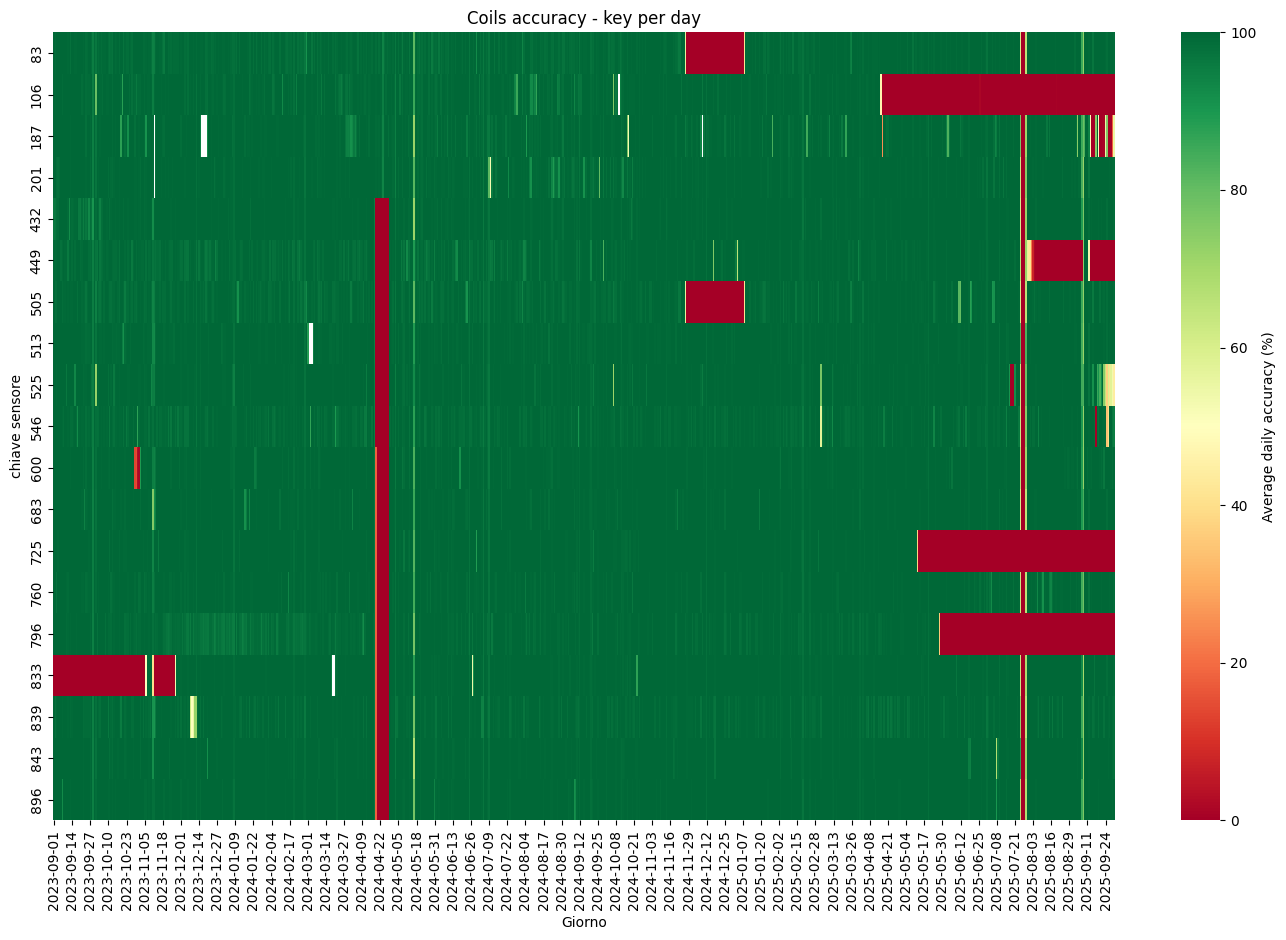

Giornate-spira anomale (|z_mod| > 3.5): 2715


,chiave,data,accuratezza,median_acc,MAD,modified_zscore
14394,896,2025-07-28,0.000000,100.000000,0.000000,-6.745000e+10
14393,896,2025-07-27,0.000000,100.000000,0.000000,-6.745000e+10
7847,600,2024-04-25,0.000000,100.000000,0.000000,-6.745000e+10
7846,600,2024-04-24,0.000000,100.000000,0.000000,-6.745000e+10
7848,600,2024-04-26,0.000000,100.000000,0.000000,-6.745000e+10
...,...,...,...,...,...,...
4796,505,2024-04-18,95.458333,99.291667,0.708333,-3.650235e+00
7079,546,2024-04-18,95.458333,99.291667,0.708333,-3.650235e+00
5137,505,2025-03-25,95.466667,99.291667,0.708333,-3.642300e+00
571,83,2025-03-25,95.466667,99.291667,0.708333,-3.642300e+00


In [11]:
acc_pivot = (
    df.assign(giorno=df['timestamp'].dt.date)
      .groupby(['chiave', 'giorno'])['accuratezza']
      .mean()
      .unstack()
)

fig, ax = plt.subplots(figsize=(14, max(2, len(acc_pivot) * 0.5)))
sns.heatmap(acc_pivot, cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Average daily accuracy (%)'}, ax=ax)
ax.set_title('Coils accuracy - key per day')
ax.set_xlabel('Giorno')
ax.set_ylabel('chiave sensore')
plt.tight_layout()
plt.show()

# --- MAD-based residual deviation ---
MAD_THRESHOLD = 3.5  # standard threshold for modified z-score

acc_long = (
    acc_pivot.stack()
             .rename('accuratezza')
             .reset_index()
             .rename(columns={'giorno': 'data'})
)

# per-sensor median and MAD
sensor_stats = (
    acc_long.groupby('chiave')['accuratezza']
            .agg(median_acc='median',
                 MAD=lambda x: (x - x.median()).abs().median())
            .reset_index()
)

acc_long = acc_long.merge(sensor_stats, on='chiave')
acc_long['residual'] = acc_long['accuratezza'] - acc_long['median_acc']
# modified z-score (Iglewicz & Hoaglin 1993): 0.6745 * residual / MAD
acc_long['modified_zscore'] = 0.6745 * acc_long['residual'] / (acc_long['MAD'] + 1e-9)
acc_long['is_anomaly'] = acc_long['modified_zscore'].abs() > MAD_THRESHOLD

anomalies = acc_long[acc_long['is_anomaly']].sort_values('modified_zscore')
print(f"Giornate-spira anomale (|z_mod| > {MAD_THRESHOLD}): {len(anomalies)}")
anomalies[['chiave', 'data', 'accuratezza', 'median_acc', 'MAD', 'modified_zscore']]

Come si comporta il traffico nelle 24 ore di un giorno medio, separando per giorno della settimana? Quanto è regolare il pattern? Quanto varia tra spire diverse della stessa categoria (es. due spire entrambe in centro)?

Esiste una stagionalità settimanale (lun-ven vs sab-dom)? Una stagionalità annuale (estate vs inverno, agosto)? Le due stagionalità interagiscono?

Quanto e come il meteo influenza il traffico? La pioggia aumenta o diminuisce i flussi? La risposta non è ovvia e dipende dalla strada.
Quanto sono "rumorosi" i dati? Calcolate la deviazione standard ora-per-ora rispetto al pattern stagionale: dove vivono le anomalie naturalmente non rilevate?

Qual è la distribuzione del dataset di accuratezza? Quante ore-spira hanno accuratezza inferiore a 100%? A 50%? A 0%? Queste vanno trattate, e dovete decidere come (escluderle? imputarle? marcarle?).

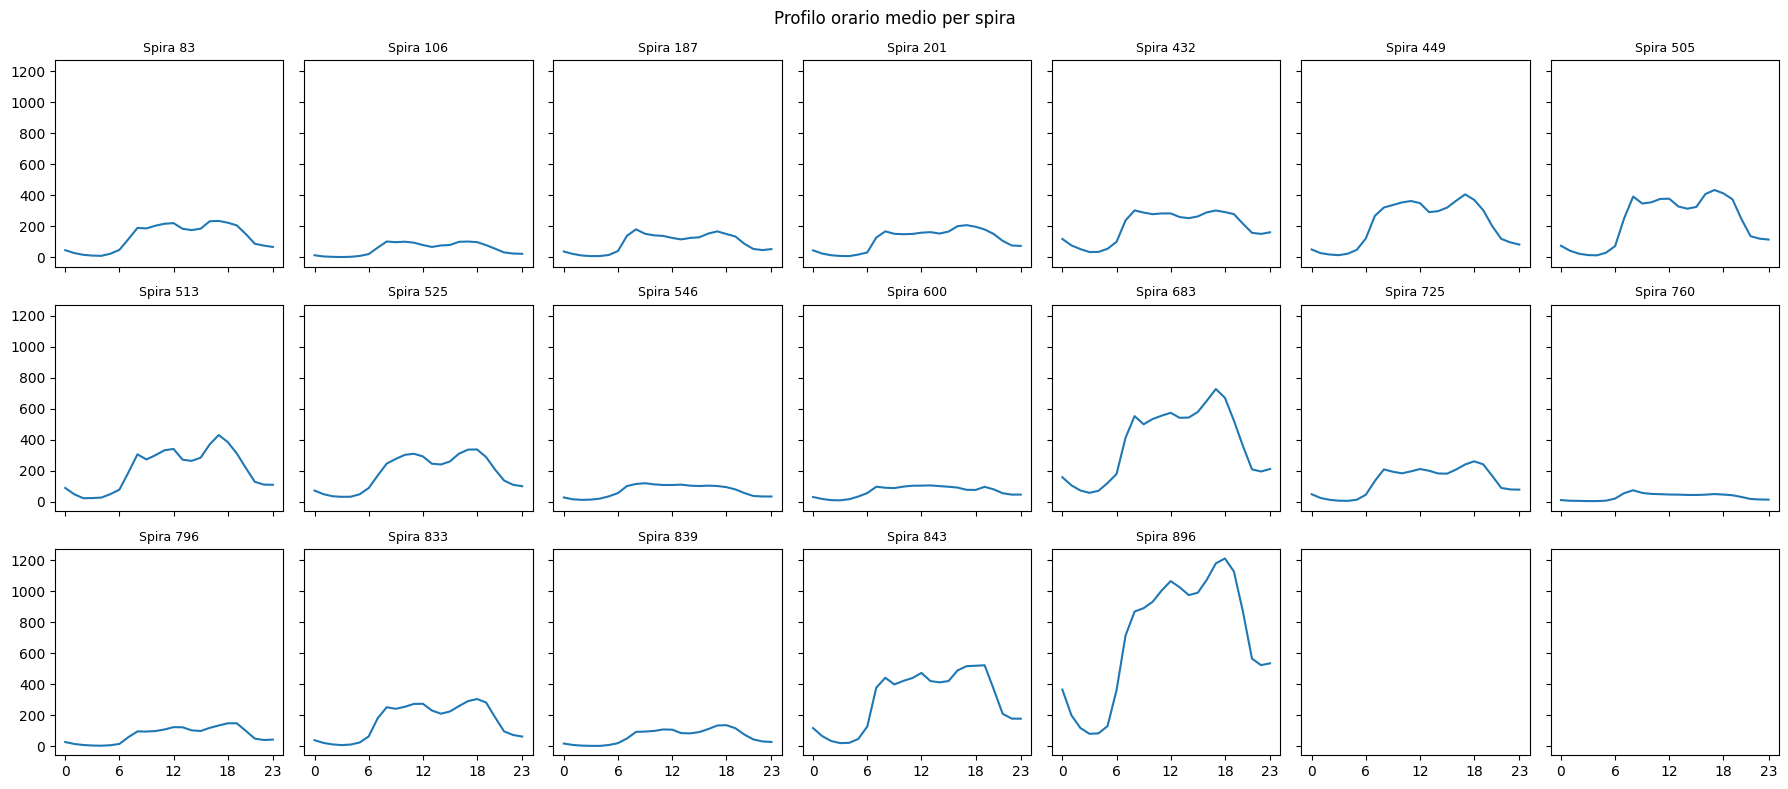

In [12]:
coil = sorted(df['chiave'].unique())

fig, axes = plt.subplots(3, 7, figsize=(18, 8), sharex=True, sharey=True)

for ax, coil in zip(axes.flatten(), coil):

    sub = (
        df[df['chiave'] == coil]
        .groupby('ora_del_giorno')['conteggio_veicoli']
        .mean()
        .reset_index()
    )

    ax.plot(sub['ora_del_giorno'], sub['conteggio_veicoli'])
    ax.set_title(f'Spira {coil}', fontsize=9)
    ax.set_xticks([0, 6, 12, 18, 23])

plt.suptitle('Profilo orario medio per spira')
plt.tight_layout()
plt.show()

Let's make a comparison between two coils both located close to the city center, the 869 and 725, anche both close by each other. 

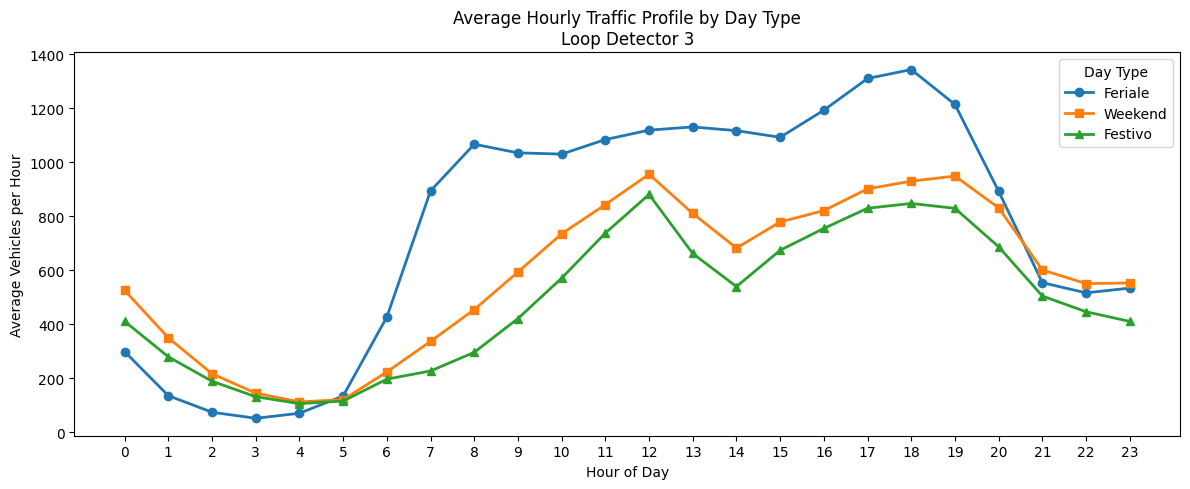

In [13]:
df_spira = df[df['chiave'] == 896]

profilo_g = (
    df_spira.groupby(['tipo_giorno', 'ora_del_giorno'])['conteggio_veicoli']
             .mean()
             .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for day_type, marker in zip(['feriale', 'weekend', 'festivo'], ['o', 's', '^']):
    subset = profilo_g[profilo_g['tipo_giorno'] == day_type]

    if not subset.empty:
        ax.plot(
            subset['ora_del_giorno'],
            subset['conteggio_veicoli'],
            marker=marker,
            linewidth=2,
            label=day_type.capitalize()
        )

ax.set_title(f'Average Hourly Traffic Profile by Day Type\nLoop Detector {3}')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Vehicles per Hour')
ax.set_xticks(range(24))
ax.legend(title='Day Type')

plt.tight_layout()
plt.show()

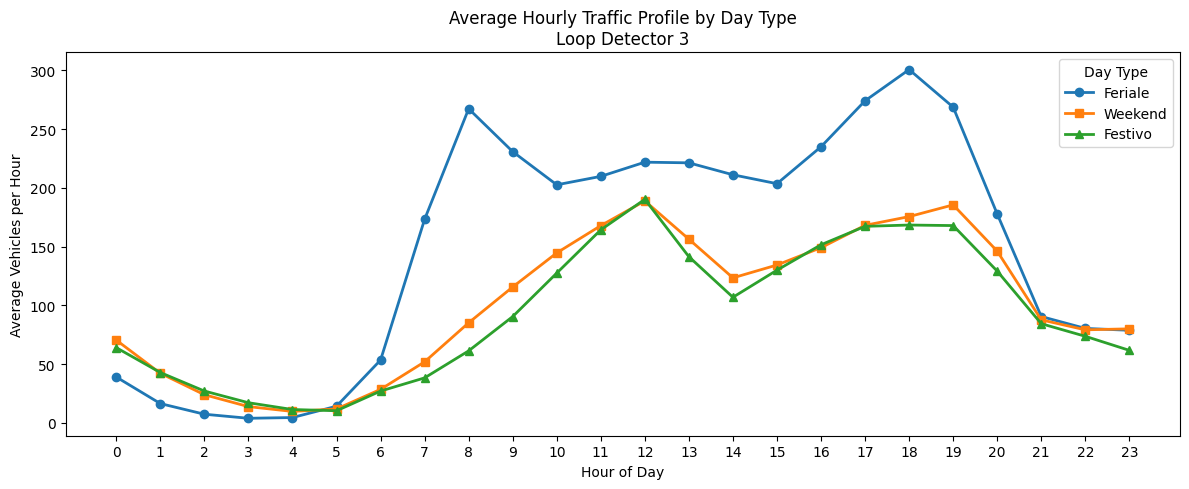

In [14]:
df_spira = df[df['chiave'] == 725]

profilo_g = (
    df_spira.groupby(['tipo_giorno', 'ora_del_giorno'])['conteggio_veicoli']
             .mean()
             .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for day_type, marker in zip(['feriale', 'weekend', 'festivo'], ['o', 's', '^']):
    subset = profilo_g[profilo_g['tipo_giorno'] == day_type]

    if not subset.empty:
        ax.plot(
            subset['ora_del_giorno'],
            subset['conteggio_veicoli'],
            marker=marker,
            linewidth=2,
            label=day_type.capitalize()
        )

ax.set_title(f'Average Hourly Traffic Profile by Day Type\nLoop Detector {3}')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Vehicles per Hour')
ax.set_xticks(range(24))
ax.legend(title='Day Type')

plt.tight_layout()
plt.show()

Let's see if there is a seasonal trend, a distinction between summer and winter. 

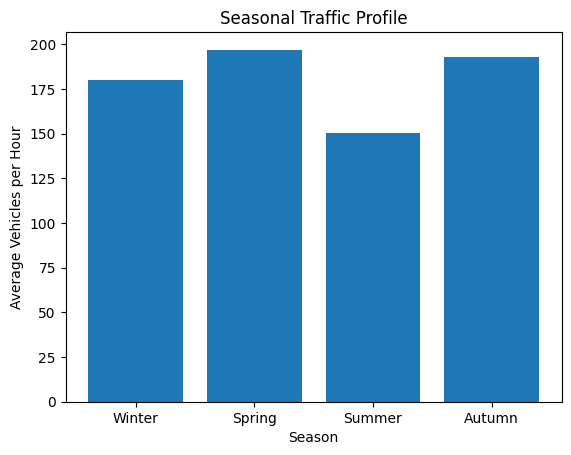

In [15]:
df['data'] = pd.to_datetime(df.data, format='%Y-%m-%d')
df['month'] = df['data'].dt.month

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

df['season'] = df['month'].map(season_map)
df

seasonal_profile = (
    df.groupby('season')['conteggio_veicoli']
            .mean()
            .reindex(['Winter', 'Spring', 'Summer', 'Autumn'])
)

plt.bar(seasonal_profile.index, seasonal_profile.values)
plt.title('Seasonal Traffic Profile')
plt.xlabel('Season')
plt.ylabel('Average Vehicles per Hour')
plt.show()

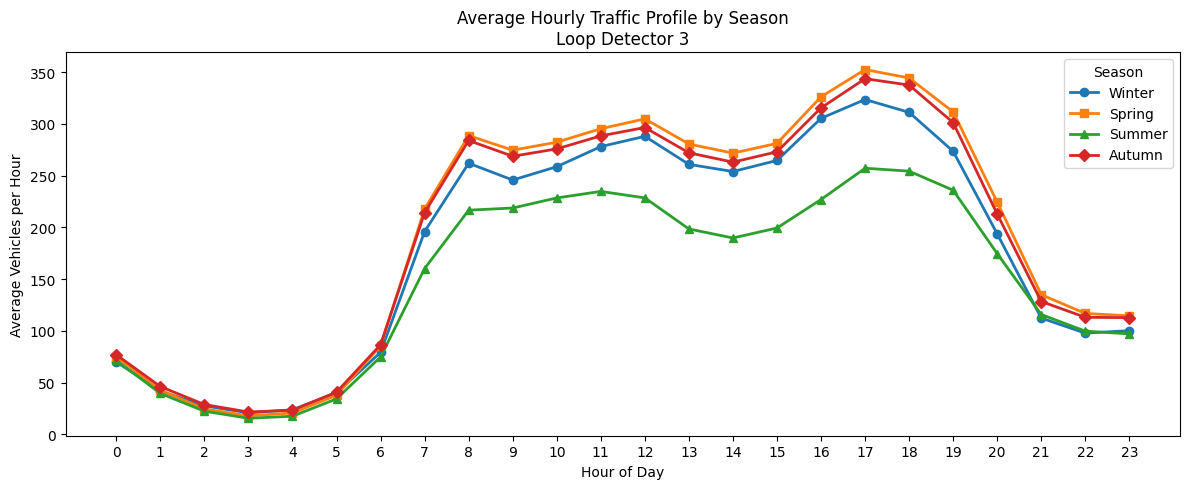

In [16]:
season_hour = (
    df.groupby(['season', 'ora_del_giorno'])['conteggio_veicoli']
            .mean()
            .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for season, marker in zip(['Winter', 'Spring', 'Summer', 'Autumn'], ['o', 's', '^', 'D']):
    subset = season_hour[season_hour['season'] == season]

    if not subset.empty:
        ax.plot(
            subset['ora_del_giorno'],
            subset['conteggio_veicoli'],
            marker=marker,
            linewidth=2,
            label=season.capitalize()
        )

ax.set_title(f'Average Hourly Traffic Profile by Season\nLoop Detector {3}')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Vehicles per Hour')
ax.set_xticks(range(24))
ax.legend(title='Season')

plt.tight_layout()
plt.show()

# Baseline 1

Let's break down the seasonality and the trend

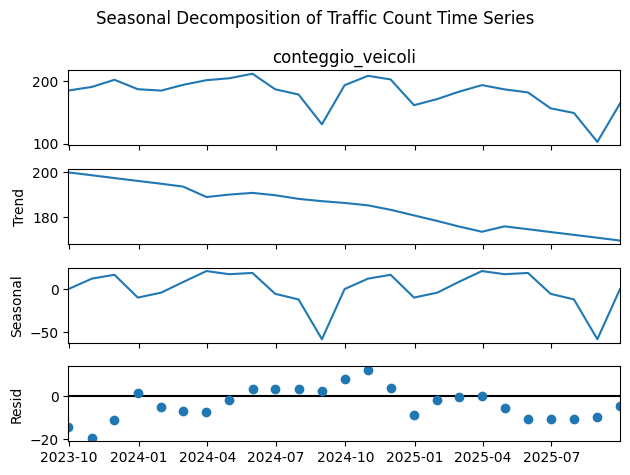

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels

df = df.sort_values('data')

monthly = (
    df.set_index('data')['conteggio_veicoli']
      .resample('ME')
      .mean()
)

statsmodels.tsa.seasonal.seasonal_decompose(
    monthly, 
    model='additive', 
    period=12, 
    extrapolate_trend='freq'
    ).plot()
plt.suptitle('Seasonal Decomposition of Traffic Count Time Series')
plt.tight_layout()
plt.show()


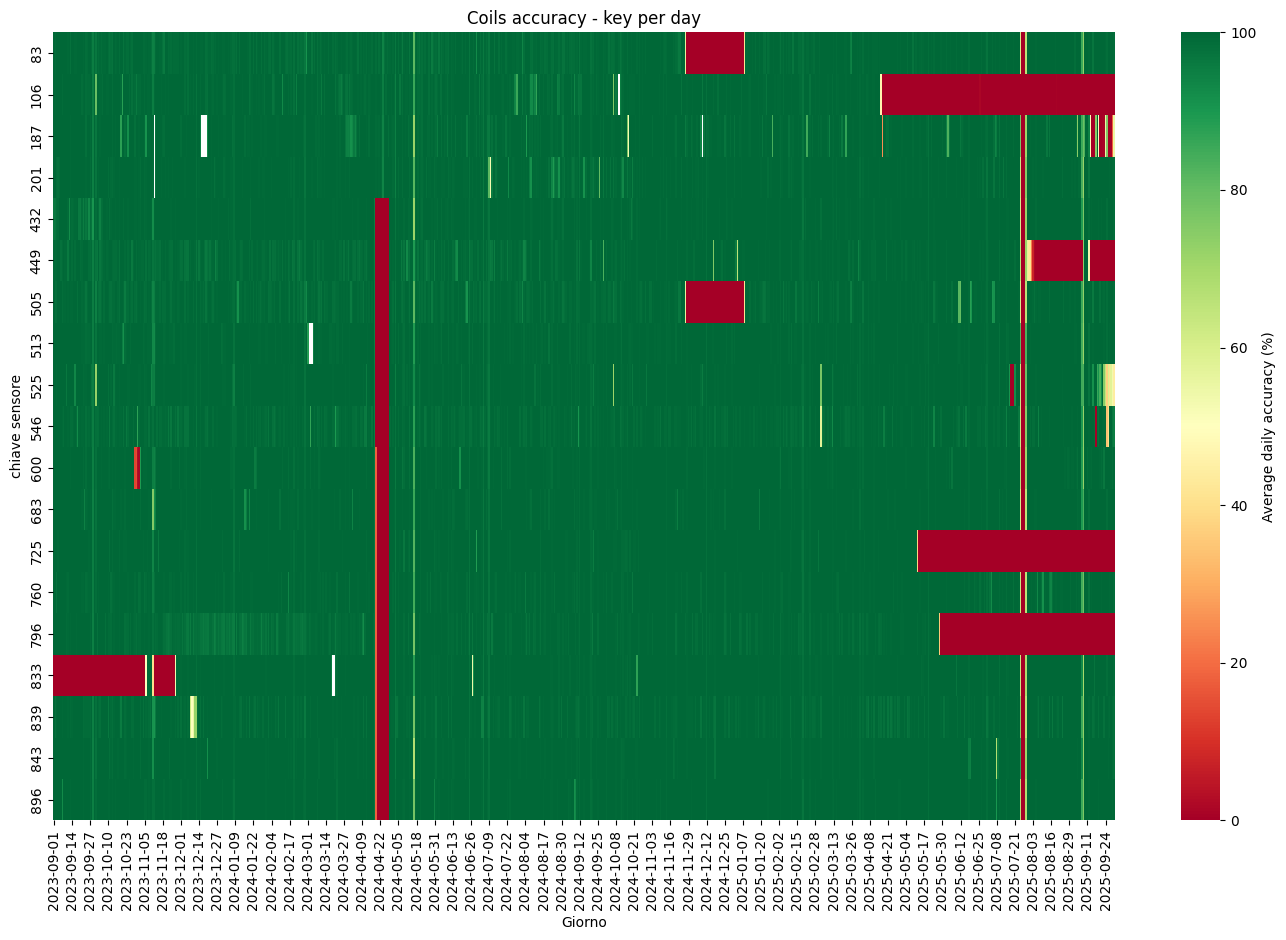

Giornate-spira anomale (|z_mod| > 3.5): 2715


,chiave,data,accuratezza,median_acc,MAD,modified_zscore
14394,896,2025-07-28,0.000000,100.000000,0.000000,-6.745000e+10
14393,896,2025-07-27,0.000000,100.000000,0.000000,-6.745000e+10
7847,600,2024-04-25,0.000000,100.000000,0.000000,-6.745000e+10
7846,600,2024-04-24,0.000000,100.000000,0.000000,-6.745000e+10
7848,600,2024-04-26,0.000000,100.000000,0.000000,-6.745000e+10
...,...,...,...,...,...,...
4796,505,2024-04-18,95.458333,99.291667,0.708333,-3.650235e+00
7079,546,2024-04-18,95.458333,99.291667,0.708333,-3.650235e+00
5137,505,2025-03-25,95.466667,99.291667,0.708333,-3.642300e+00
571,83,2025-03-25,95.466667,99.291667,0.708333,-3.642300e+00


In [18]:
acc_pivot = (
    df.assign(giorno=df['timestamp'].dt.date)
      .groupby(['chiave', 'giorno'])['accuratezza']
      .mean()
      .unstack()
)

fig, ax = plt.subplots(figsize=(14, max(2, len(acc_pivot) * 0.5)))
sns.heatmap(acc_pivot, cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Average daily accuracy (%)'}, ax=ax)
ax.set_title('Coils accuracy - key per day')
ax.set_xlabel('Giorno')
ax.set_ylabel('chiave sensore')
plt.tight_layout()
plt.show()

# --- MAD-based residual deviation ---
MAD_THRESHOLD = 3.5  # standard threshold for modified z-score

acc_long = (
    acc_pivot.stack()
             .rename('accuratezza')
             .reset_index()
             .rename(columns={'giorno': 'data'})
)

# per-sensor median and MAD
sensor_stats = (
    acc_long.groupby('chiave')['accuratezza']
            .agg(median_acc='median',
                 MAD=lambda x: (x - x.median()).abs().median())
            .reset_index()
)

acc_long = acc_long.merge(sensor_stats, on='chiave')
acc_long['residual'] = acc_long['accuratezza'] - acc_long['median_acc']
# modified z-score (Iglewicz & Hoaglin 1993): 0.6745 * residual / MAD
acc_long['modified_zscore'] = 0.6745 * acc_long['residual'] / (acc_long['MAD'] + 1e-9)
acc_long['is_anomaly'] = acc_long['modified_zscore'].abs() > MAD_THRESHOLD

anomalies = acc_long[acc_long['is_anomaly']].sort_values('modified_zscore')
print(f"Giornate-spira anomale (|z_mod| > {MAD_THRESHOLD}): {len(anomalies)}")
anomalies[['chiave', 'data', 'accuratezza', 'median_acc', 'MAD', 'modified_zscore']]

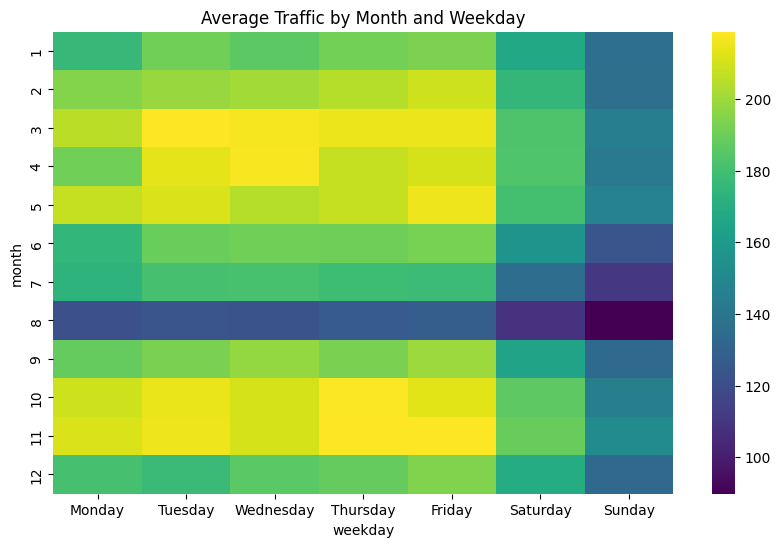

In [19]:
df['month'] = df['data'].dt.month
df['weekday'] = df['data'].dt.day_name()

heatmap_data = (
    df.groupby(['month', 'weekday'])['conteggio_veicoli']
      .mean()
      .unstack()
)

weekday_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

heatmap_data = heatmap_data[weekday_order]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='viridis')
plt.title('Average Traffic by Month and Weekday')
plt.show()

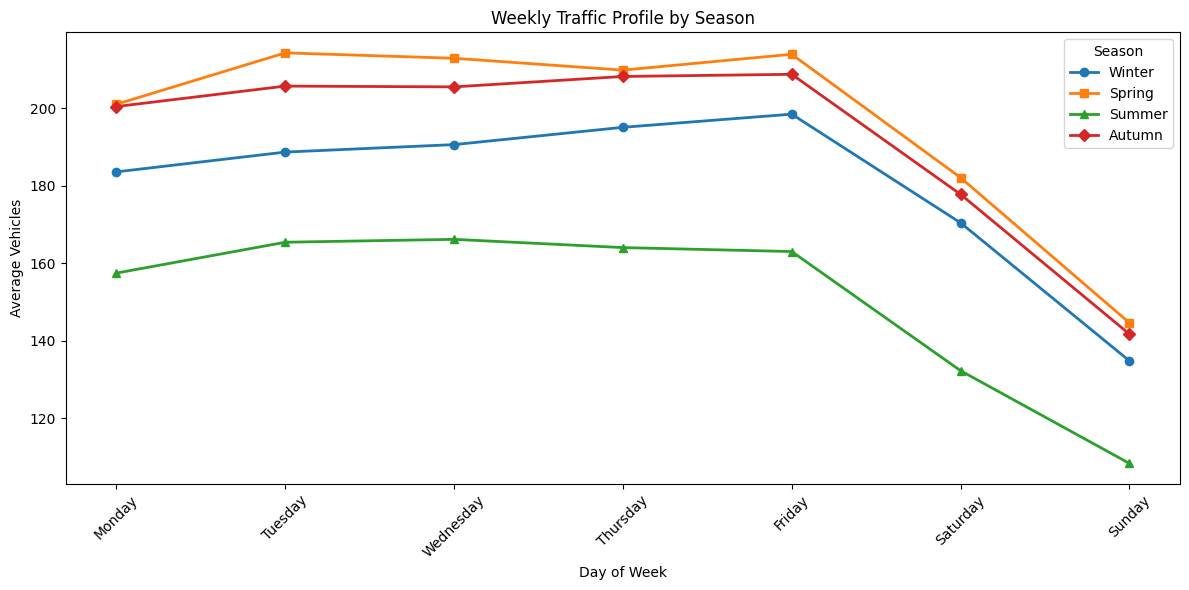

In [20]:
seasonal_week = (
    df.groupby(['season', 'weekday'])['conteggio_veicoli']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

markers = {
    'Winter': 'o',
    'Spring': 's',
    'Summer': '^',
    'Autumn': 'D'
}

for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    sub = seasonal_week[seasonal_week['season'] == season]

    sub = sub.set_index('weekday').reindex(weekday_order).reset_index()

    ax.plot(
        sub['weekday'],
        sub['conteggio_veicoli'],
        marker=markers[season],
        linewidth=2,
        label=season
    )

ax.set_title('Weekly Traffic Profile by Season')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Vehicles')
ax.legend(title='Season')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Let's see how the weather affects the traffic jam. 

In [21]:
meteo_effect = (
    df.groupby('tempo')['conteggio_veicoli']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)